# BrushCue Example: Color Rectangle

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/color_rectangle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/color-rectangle

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


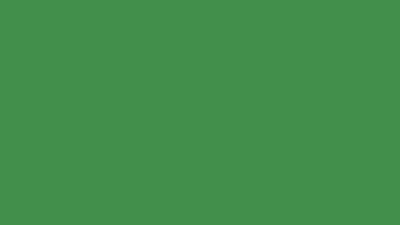

In [1]:
import io
from PIL import Image

import brushcue as bc

width = 1920
height = 1080
rectangle_size_i = bc.Vector2i.from_components(width, height)
fill_color = bc.RGBAColor.from_components(0.26, 0.56, 0.3, 1.0)
graph = bc.Composition.painter(
    bc.Painter.new().add_rectangle_with_render_style(
        bc.Point2f.from_components(
            rectangle_size_i.to_vector2f().scalar_multiply(0.5).x(),
            rectangle_size_i.to_vector2f().scalar_multiply(0.5).y(),
        ),
        rectangle_size_i.to_vector2f(),
        0.0,
        bc.RenderStyle.fill_only(
            bc.Fill.solid(bc.ProfiledColor.from_rgba_srgb(fill_color))
        ),
        bc.Transform2.identity().to_list(),
    )
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
